# Sensitivity of kilonova light curves to atomic-physics assumptions

### High-ionization absorption opacity and parametrized departures from LTE

This notebook includes two sets of **POSSIS** radiative-transfer calculations for the same two-component kilonova ejecta model. The goal is to quantify how broadband light curves are affected by:

1. underestimated absorption opacity at high temperatures, where ionization stages above those included in the opacity tables may become important;
2. parametrized departures from LTE through matter-radiation temperature decoupling and changes in the bound-bound opacity.

NB: The calculations are sensitivity tests, not new atomic-structure calculations or self-consistent NLTE solutions.

## Physical question and comparison strategy

All modified simulations are compared with the same LTE fiducial model. The individual temperature and opacity tests help identify the origin of the changes, while the joint models quantify their net effect on the light curves.

For every filter we show:
- the absolute AB magnitude at 10 pc;
- the difference between the modified and fiducial model

In [212]:
from pathlib import Path
from collections import OrderedDict
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import sncosmo
from IPython.display import Markdown, display

%matplotlib inline

DAY = 86400.0
H0 = 67.0                    # km s^-1 Mpc^-1
CLIGHT = 2.99792458e5        # km s^-1
DISTANCE_MPC = 1.0e-5        # 10 pc: output magnitudes are absolute magnitudes
REDSHIFT = H0 * DISTANCE_MPC / CLIGHT

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "lines.linewidth": 2.0,
})

# The notebook works when placed next to either outputs/ or outputs_chatgpt/.
output_candidates = [
    Path("outputs"),
    ]
OUTPUT_DIR = next((p for p in output_candidates if p.is_dir()), None)
if OUTPUT_DIR is None:
    raise FileNotFoundError(
        "Could not find the model directory. Put the extracted HDF5 files in "
        "outputs/, or edit output_candidates above."
    )

FIGURE_DIR = Path("figures_for_talk")
FIGURE_DIR.mkdir(exist_ok=True)
print(f"Reading models from: {OUTPUT_DIR.resolve()}")

Reading models from: /Users/mbull/Documents/Work/Projects/POSSIS/work/retreat/mattia_kn_uncertainties/outputs


## Ejecta Model

The fiducial model contains two components: (1) a dynamical ejecta component of $0.005\,M_\odot$, expanding at an average velocity of 0.2c and with an averaged $Y_e$ of 0.2; and (2) a wind ejecta component of $0.050\,M_\odot$, expanding at an average velocity of 0.05c and with a uniform $Y_e$ of 0.3. All calculations use $10^6$ Monte Carlo packets. Observables are computed for 11 viewing angles. The observer viewing angle is controlled by the parametere `VIEW_INDEX` (ranging from 0, edge-on, to 10, face-on).

The registry below gives short, readable names to the simulations.

In [213]:
stem = "nph1.0e+06_dyn0.005-0.20-0.20_wind0.050-0.05-0.30"

def first_existing(*filenames):
    # Accept the compact and explicit naming styles used by different runs.
    return next((name for name in filenames if (OUTPUT_DIR / name).is_file()), filenames[0])

MODELS = OrderedDict([
    ("baseline", dict(
        file=f"{stem}.hdf5",
        label="LTE baseline", color="black", ls="-")),

    # High-temperature true-absorption tests
    ("HighT-kabs2", dict(
        file=first_existing(
            f"{stem}_LTE_ncrit1e+09_fT1.00_fk1.00_feps1.00_Tabove2e4kabsx2.hdf5",
            f"{stem}_Tabove2e4kabsx2.hdf5"),
        label=r"$T>2\times10^4$ K: $k_{\rm abs}\times2$",
        color="#56B4E9", ls="-")),
    ("HighT-kabs10", dict(
        file=first_existing(
            f"{stem}_LTE_ncrit1e+09_fT1.00_fk1.00_feps1.00_Tabove2e4kabsx10.hdf5",
            f"{stem}_Tabove2e4kabsx10.hdf5"),
        label=r"$T>2\times10^4$ K: $k_{\rm abs}\times10$",
        color="#0072B2", ls="-")),

    # Individual LTE-departure ingredients
    ("LTE temp_only", dict(
        file=f"{stem}_LTE_ncrit1e+09_fT1.25_fk1.00_feps1.00.hdf5",
        label=r"temperature only: $(f_T,f_\kappa)=(1.25,1)$",
        color="#CC79A7", ls=":")),
    ("LTE opacity_only", dict(
        file=f"{stem}_LTE_ncrit1e+09_fT1.00_fk0.75_feps1.00.hdf5",
        label=r"opacity only: $(f_T,f_\kappa)=(1,0.75)$",
        color="#E69F00", ls="--")),

    # New two-ingredient LTE-departure cases
    ("LTE temp + opacity", dict(
        file=f"{stem}_LTE_ncrit1e+09_fT1.25_fk0.75_feps1.00_Tabove2e4kabsx1.hdf5",
        label=r"LTE: $(f_T,f_\kappa)=(1.25,0.75)$",
        color="#0072B2", ls="-")),
#    ("strong", dict(
#        file=first_existing(
#            f"{stem}_LTE_ncrit1e+09_fT1.5_fk0.5_feps1.0.hdf5",
#            f"{stem}_LTE_ncrit1e+09_fT1.5_fk0.5_feps1.00.hdf5",
#            f"{stem}_LTE_ncrit1e+09_fT1.50_fk0.50_feps1.00.hdf5"),
#        label=r"stronger: $(f_T,f_\kappa)=(1.50,0.50)$",
#        color="#D55E00", ls="-")),

    # LTE departure combined with high-temperature absorption
    ("LTE_highT-kabs2", dict(
        file=f"{stem}_LTE_ncrit1e+09_fT1.25_fk0.75_feps1.00_Tabove2e4kabsx2.hdf5",
        label=r"LTE + high-$T$ $k_{\rm abs}\times2$",
        color="#009E73", ls="--")),
    ("LTE_highT-kabs10", dict(
        file=f"{stem}_LTE_ncrit1e+09_fT1.25_fk0.75_feps1.00_Tabove2e4kabsx10.hdf5",
        label=r"LTE + high-$T$ $k_{\rm abs}\times10$",
        color="#CC79A7", ls="-")),
])

FILTERS = OrderedDict([
    ("sdssu", r"$u$"),
    ("ps1::r", r"$r$"),
    ("ps1::z", r"$z$"),
    ("2massks", r"$K_s$"),
])

VIEW_INDEX = 10
TIME_LIMITS = (0.1, 10.0)
MAG_LIMITS = (-8.0, -19.0)
DELTA_LIMITS = (-3.0, 3.0)

AVAILABLE_MODELS = {
    key for key, cfg in MODELS.items()
    if (OUTPUT_DIR / cfg["file"]).is_file()
}
if "baseline" not in AVAILABLE_MODELS:
    raise FileNotFoundError(f"Missing required baseline: {MODELS['baseline']['file']}")

missing = [key for key in MODELS if key not in AVAILABLE_MODELS]
if missing:
    print("Pending or missing models (their curves will be skipped):")
    for key in missing:
        print(f"  {key}: {MODELS[key]['file']}")

display(Markdown(
    "| Key | Plot label | Status |\n|---|---|---|\n" +
    "\n".join(
        f"| `{key}` | {cfg['label']} | "
        f"{'available' if key in AVAILABLE_MODELS else 'pending'} |"
        for key, cfg in MODELS.items()
    )
))

| Key | Plot label | Status |
|---|---|---|
| `baseline` | LTE baseline | available |
| `HighT-kabs2` | $T>2\times10^4$ K: $k_{\rm abs}\times2$ | available |
| `HighT-kabs10` | $T>2\times10^4$ K: $k_{\rm abs}\times10$ | available |
| `LTE temp_only` | temperature only: $(f_T,f_\kappa)=(1.25,1)$ | available |
| `LTE opacity_only` | opacity only: $(f_T,f_\kappa)=(1,0.75)$ | available |
| `LTE temp + opacity` | LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | available |
| `LTE_highT-kabs2` | LTE + high-$T$ $k_{\rm abs}\times2$ | available |
| `LTE_highT-kabs10` | LTE + high-$T$ $k_{\rm abs}\times10$ | available |

## Read the spectra and compute broad-band light curves

The code first reads the dimensions from the fiducial model and then allocates the magnitude arrays. This avoids relying on variables left in memory by an earlier notebook session. Every model is checked against the fiducial model time, wavelength, and viewing angle grids.

The Stokes-$I$ spectra are converted to AB magnitudes using `sncosmo`. The original POSSIS models are at 1 Mpc and are therefore rescaled to 10 pc.

In [214]:
def read_model_axes(path):
    with h5py.File(path, "r") as handle:
        obs = handle["observables"]
        wave = np.asarray(obs["wave"], dtype=float)
        time_days = np.asarray(obs["time"], dtype=float) / DAY
        shape = obs["stokes"].shape
    if len(shape) != 4 or shape[-1] < 1:
        raise ValueError(f"Unexpected Stokes-array shape {shape} in {path.name}")
    return time_days, wave, shape


baseline_path = OUTPUT_DIR / MODELS["baseline"]["file"]
time_days, wave_rest, stokes_shape = read_model_axes(baseline_path)
NOBS, NTIME, NWAVE, NSTOKES = stokes_shape

if VIEW_INDEX >= NOBS:
    raise IndexError(f"VIEW_INDEX={VIEW_INDEX}, but only {NOBS} observers are available")

wave_observed = wave_rest * (1.0 + REDSHIFT)
distance_scale = (1.0 / DISTANCE_MPC) ** 2

MAGS = {}
for key, cfg in MODELS.items():
    if key not in AVAILABLE_MODELS:
        continue
    path = OUTPUT_DIR / cfg["file"]
    model_time, model_wave, model_shape = read_model_axes(path)
    if model_shape != stokes_shape:
        raise ValueError(f"Grid-shape mismatch for {key}: {model_shape} != {stokes_shape}")
    if not np.allclose(model_time, time_days):
        raise ValueError(f"Time-grid mismatch for {key}")
    if not np.allclose(model_wave, wave_rest):
        raise ValueError(f"Wavelength-grid mismatch for {key}")

    magnitudes = np.full((len(FILTERS), NOBS, NTIME), np.nan)
    with h5py.File(path, "r") as handle:
        stokes = handle["observables"]["stokes"]
        for iobs in range(NOBS):
            flux = np.asarray(stokes[iobs, :, :, 0], dtype=float) * distance_scale
            source = sncosmo.TimeSeriesSource(time_days, wave_observed, flux)
            for ifilt, band in enumerate(FILTERS):
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", RuntimeWarning)
                    magnitudes[ifilt, iobs] = source.bandmag(band, "ab", time_days)
    MAGS[key] = magnitudes

print(
    f"Loaded {len(MAGS)} available models: {NOBS} observers, {NTIME} epochs "
    f"({time_days.min():.3f}--{time_days.max():.1f} d), {NWAVE} wavelength bins."
)

Loaded 8 available models: 11 observers, 100 epochs (0.103--30.9 d), 1000 wavelength bins.


In [215]:
def finite_pair(y1, y2):
    return np.isfinite(y1) & np.isfinite(y2)


def save_figure(fig, name):
    fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")


def plot_light_curve_comparison(model_keys, figure_name, delta_limits=DELTA_LIMITS):
    # Plot absolute magnitudes and modified-minus-baseline residuals.
    model_keys = [key for key in model_keys if key in MAGS]
    fig, axes = plt.subplots(
        2, len(FILTERS), figsize=(18, 7), sharex="col",
        gridspec_kw={"height_ratios": [2.0, 1.0], "hspace": 0.05, "wspace": 0.18},
    )

    for ifilt, (band, band_label) in enumerate(FILTERS.items()):
        ax, ax_delta = axes[:, ifilt]
        baseline = MAGS["baseline"][ifilt, VIEW_INDEX]

        for key in model_keys:
            cfg = MODELS[key]
            y = MAGS[key][ifilt, VIEW_INDEX]
            ax.plot(time_days, y, color=cfg["color"], ls=cfg["ls"],
                    label=cfg["label"])
            if key != "baseline":
                valid = finite_pair(y, baseline)
                ax_delta.plot(time_days[valid], (y - baseline)[valid],
                              color=cfg["color"], ls=cfg["ls"])

        ax.set_xscale("log")
        ax.set_xlim(*TIME_LIMITS)
        ax.set_ylim(*MAG_LIMITS)
        ax.set_title(band_label)
        ax.grid(alpha=0.18)

        ax_delta.axhline(0.0, color="0.35", lw=1.2, ls="--")
        ax_delta.set_xscale("log")
        ax_delta.set_xlim(*TIME_LIMITS)
        ax_delta.set_ylim(*delta_limits)
        ax_delta.set_xlabel("Time since merger [days]")
        ax_delta.grid(alpha=0.18)

        ax_delta.axhline(y=-1,ls=':',c='grey')
        ax_delta.axhline(y=1,ls=':',c='grey')

        if ifilt == 0:
            ax.set_ylabel(r"$M_{\rm AB}$")
            ax_delta.set_ylabel(r"$\Delta m$")
        else:
            ax.tick_params(labelleft=False)
            ax_delta.tick_params(labelleft=False)

    axes[0, 0].legend(frameon=False, loc="best")
    fig.align_ylabels(axes[:, 0])
    save_figure(fig, figure_name)
    plt.show()


def peak_table(model_keys, tmin=0.15, tmax=10.0):
    # Display peak time and magnitude for each model and filter.
    in_window = (time_days >= tmin) & (time_days <= tmax)
    rows = ["| Model | Filter | Peak time [d] | Peak magnitude | Shift from baseline |",
            "|---|---:|---:|---:|---:|"]
    for key in model_keys:
        if key not in MAGS:
            continue
        for ifilt, band_label in enumerate(FILTERS.values()):
            y = MAGS[key][ifilt, VIEW_INDEX]
            valid = in_window & np.isfinite(y)
            if not np.any(valid):
                continue
            idx = np.where(valid)[0][np.argmin(y[valid])]
            baseline_at_peak = np.interp(time_days[idx], time_days,
                                         MAGS["baseline"][ifilt, VIEW_INDEX])
            shift = y[idx] - baseline_at_peak
            rows.append(
                f"| {MODELS[key]['label']} | {band_label} | {time_days[idx]:.3f} | "
                f"{y[idx]:.3f} | {shift:+.3f} |"
            )
    display(Markdown("\n".join(rows)))


def maximum_difference_table(model_keys, tmin=0.2, tmax=10.0):
    # Display the largest absolute magnitude difference in a robust time window.
    rows = [f"| Model | Filter | max $|\\Delta m|$ ({tmin:g}--{tmax:g} d) | Time [d] |",
            "|---|---:|---:|---:|"]
    for key in model_keys:
        if key == "baseline" or key not in MAGS:
            continue
        for ifilt, band_label in enumerate(FILTERS.values()):
            y = MAGS[key][ifilt, VIEW_INDEX]
            base = MAGS["baseline"][ifilt, VIEW_INDEX]
            valid = ((time_days >= tmin) & (time_days <= tmax) &
                     np.isfinite(y) & np.isfinite(base))
            if not np.any(valid):
                continue
            delta = y[valid] - base[valid]
            local_idx = np.argmax(np.abs(delta))
            global_idx = np.where(valid)[0][local_idx]
            rows.append(
                f"| {MODELS[key]['label']} | {band_label} | "
                f"{abs(delta[local_idx]):.3f} | {time_days[global_idx]:.3f} |"
            )
    display(Markdown("\n".join(rows)))

# 1. Missing high-ionization absorption opacity

The opacity tables from Tanaka+2020 used in POSSIS do not include high ionization stages. At $T>2\times10^4$ K, the test calculations artificially increase the bound-bound absorption opacity:

| Test | Modified coefficient above $2\times10^4$ K |
|---|---|
| `$k_{\rm abs}\times2$` | $\kappa_{\rm abs}$ multiplied by 2 |
| `$k_{\rm abs}\times10$` | $\kappa_{\rm abs}$ multiplied by 10 |

The scattering coefficient is unchanged.

NB: these wavelength-independent factors do not predict the opacity of the missing ions; they give a sense of whether additional absorption in the hot highly-ionized ejecta can change the light curves.

/var/folders/mm/y34w0c493f155f_qjg5mprhw0000gp/T/ipykernel_10699/3999131828.py:29: RuntimeWarning: invalid value encountered in subtract
  ax_delta.plot(time_days[valid], (y - baseline)[valid],


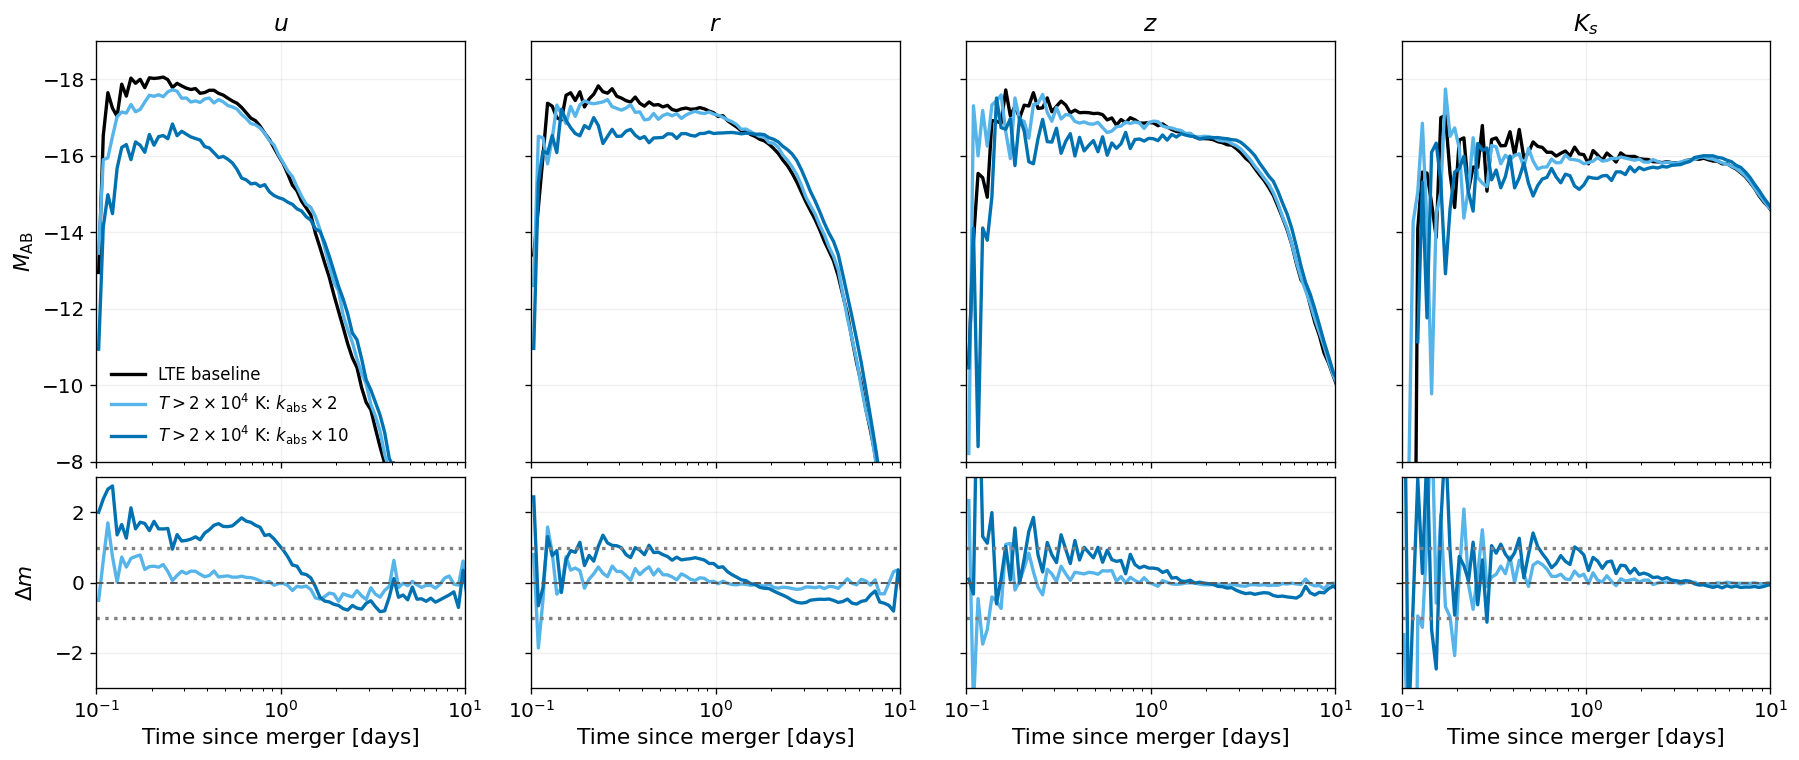

| Model | Filter | Peak time [d] | Peak magnitude | Shift from baseline |
|---|---:|---:|---:|---:|
| LTE baseline | $u$ | 0.231 | -18.056 | +0.000 |
| LTE baseline | $r$ | 0.231 | -17.826 | +0.000 |
| LTE baseline | $z$ | 0.163 | -17.719 | +0.000 |
| LTE baseline | $K_s$ | 0.173 | -17.052 | +0.000 |
| $T>2\times10^4$ K: $k_{\rm abs}\times2$ | $u$ | 0.259 | -17.725 | +0.059 |
| $T>2\times10^4$ K: $k_{\rm abs}\times2$ | $r$ | 0.259 | -17.467 | +0.168 |
| $T>2\times10^4$ K: $k_{\rm abs}\times2$ | $z$ | 0.259 | -17.601 | -0.349 |
| $T>2\times10^4$ K: $k_{\rm abs}\times2$ | $K_s$ | 0.173 | -17.742 | -0.690 |
| $T>2\times10^4$ K: $k_{\rm abs}\times10$ | $u$ | 0.259 | -16.830 | +0.954 |
| $T>2\times10^4$ K: $k_{\rm abs}\times10$ | $r$ | 0.218 | -16.995 | +0.611 |
| $T>2\times10^4$ K: $k_{\rm abs}\times10$ | $z$ | 0.194 | -16.998 | -0.013 |
| $T>2\times10^4$ K: $k_{\rm abs}\times10$ | $K_s$ | 0.154 | -16.329 | -2.465 |

In [216]:
high_temperature_models = ["baseline", "HighT-kabs2", "HighT-kabs10"]
plot_light_curve_comparison(
    high_temperature_models,
    "01_high_temperature_absorption_tests",
)
peak_table(high_temperature_models)
#maximum_difference_table(high_temperature_models)

### Reading the high-temperature comparison

- Because the correction is applied only above $2\times10^4$ K, its impact should be appreciable when a non-negligible fraction of the ejecta is hotter than this threshold, i.e. at early times ($\lesssim 1$d for this specific ejecta model).
- A persistent late-time difference can arise because early changes in absorption alter the subsequent propagation of radiation.

# 2. Parametrized departures from LTE

The LTE-departure prescription is activated progressively as the electron density decreases. In every cell and at every epoch,

$$
n_e = \frac{\rho\,\kappa_{\rm es}}{\sigma_T},
\qquad
s_{\rm NLTE}=\frac{1}{1+(n_e/n_{\rm crit})^2},
\qquad n_{\rm crit}=10^9\ {\rm cm^{-3}}.
$$

Thus $s_{\rm NLTE}\simeq0$ corresponds to a dense, approximately LTE region, while $s_{\rm NLTE}\simeq1$ identifies low-density ejecta where the prescribed departures are strongest.

Two parameters are controlled by $s_{\rm NLTE}$ and varied smoothly between a LTE case ($s_{\rm NLTE}=0$) and an approximate NLTE case ($s_{\rm NLTE}=1$): 

$$
T_{\rm gas}=T_R\left[(1-s_{\rm NLTE})+f_Ts_{\rm NLTE}\right],
$$

$$
\kappa'_{\rm bb}=\kappa_{\rm bb}^{\rm LTE}(\rho,T_{\rm gas},Y_e,t,\lambda)
\left[(1-s_{\rm NLTE})+f_\kappa s_{\rm NLTE}\right].
$$

Here $f_T$ controls the gas--radiation temperature decoupling, while $f_\kappa$ applies an additional correction to the bound--bound opacity.

| Model | $f_T$ | $f_\kappa$ |
|---|---:|---:|
| LTE baseline | 1.00 | 1.00 |
| LTE departure | 1.25 | 0.75 |

The electron density is estimated using the electron-scattering opacity evaluated at the modified gas temperature. It is therefore updated with the run, but remains an LTE-table estimate (the one from Tanaka+2020) rather than the result of a full NLTE ionization calculation.

## 2.1 Diagnostic single-ingredient runs

The temperature-only and opacity-only calculations show which ingredient drives the broadband changes.

/var/folders/mm/y34w0c493f155f_qjg5mprhw0000gp/T/ipykernel_10699/3999131828.py:29: RuntimeWarning: invalid value encountered in subtract
  ax_delta.plot(time_days[valid], (y - baseline)[valid],


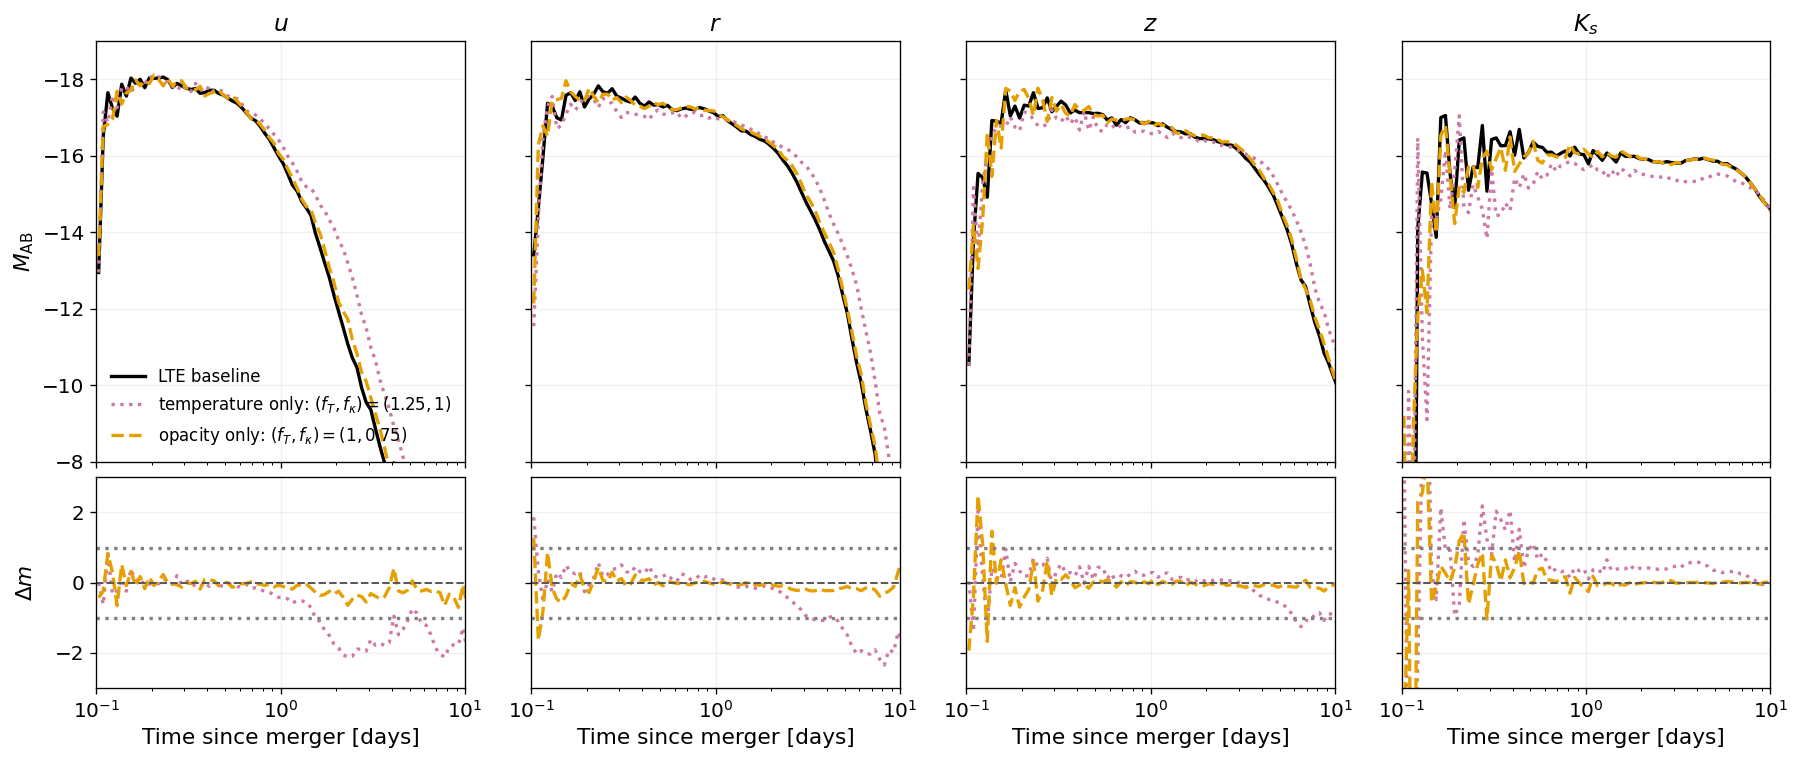

| Model | Filter | max $|\Delta m|$ (0.2--10 d) | Time [d] |
|---|---:|---:|---:|
| temperature only: $(f_T,f_\kappa)=(1.25,1)$ | $u$ | 2.125 | 7.750 |
| temperature only: $(f_T,f_\kappa)=(1.25,1)$ | $r$ | 2.351 | 8.210 |
| temperature only: $(f_T,f_\kappa)=(1.25,1)$ | $z$ | 1.258 | 6.520 |
| temperature only: $(f_T,f_\kappa)=(1.25,1)$ | $K_s$ | 2.188 | 0.274 |
| opacity only: $(f_T,f_\kappa)=(1,0.75)$ | $u$ | 0.710 | 9.212 |
| opacity only: $(f_T,f_\kappa)=(1,0.75)$ | $r$ | 0.433 | 0.231 |
| opacity only: $(f_T,f_\kappa)=(1,0.75)$ | $z$ | 0.615 | 0.274 |
| opacity only: $(f_T,f_\kappa)=(1,0.75)$ | $K_s$ | 1.428 | 0.218 |

In [217]:
single_ingredient_models = ["baseline", "LTE temp_only", "LTE opacity_only"]
plot_light_curve_comparison(
    single_ingredient_models,
    "02_single_ingredient_LTE_departure_tests",
)
maximum_difference_table(single_ingredient_models)

### Reading the diagnostic runs

- **Temperature only:** changes the gas temperature with the effect of changing the opacities and the frequencies of photons during the propagation through the ejecta.
- **Opacity only:** changes explicitly the bound-bound opacities with the effect of changing the diffusion of photons.

This test indicates that temperature decoupling produces the strongest effect.

## 2.2 Net temperature-plus-opacity tests

These runs apply the temperature and bound--bound opacity changes simultaneously. 

NB: as already said, these should be treated as **parametrized LTE-departure sensitivity tests**, not as self-consistent NLTE calculations.

/var/folders/mm/y34w0c493f155f_qjg5mprhw0000gp/T/ipykernel_10699/3999131828.py:29: RuntimeWarning: invalid value encountered in subtract
  ax_delta.plot(time_days[valid], (y - baseline)[valid],


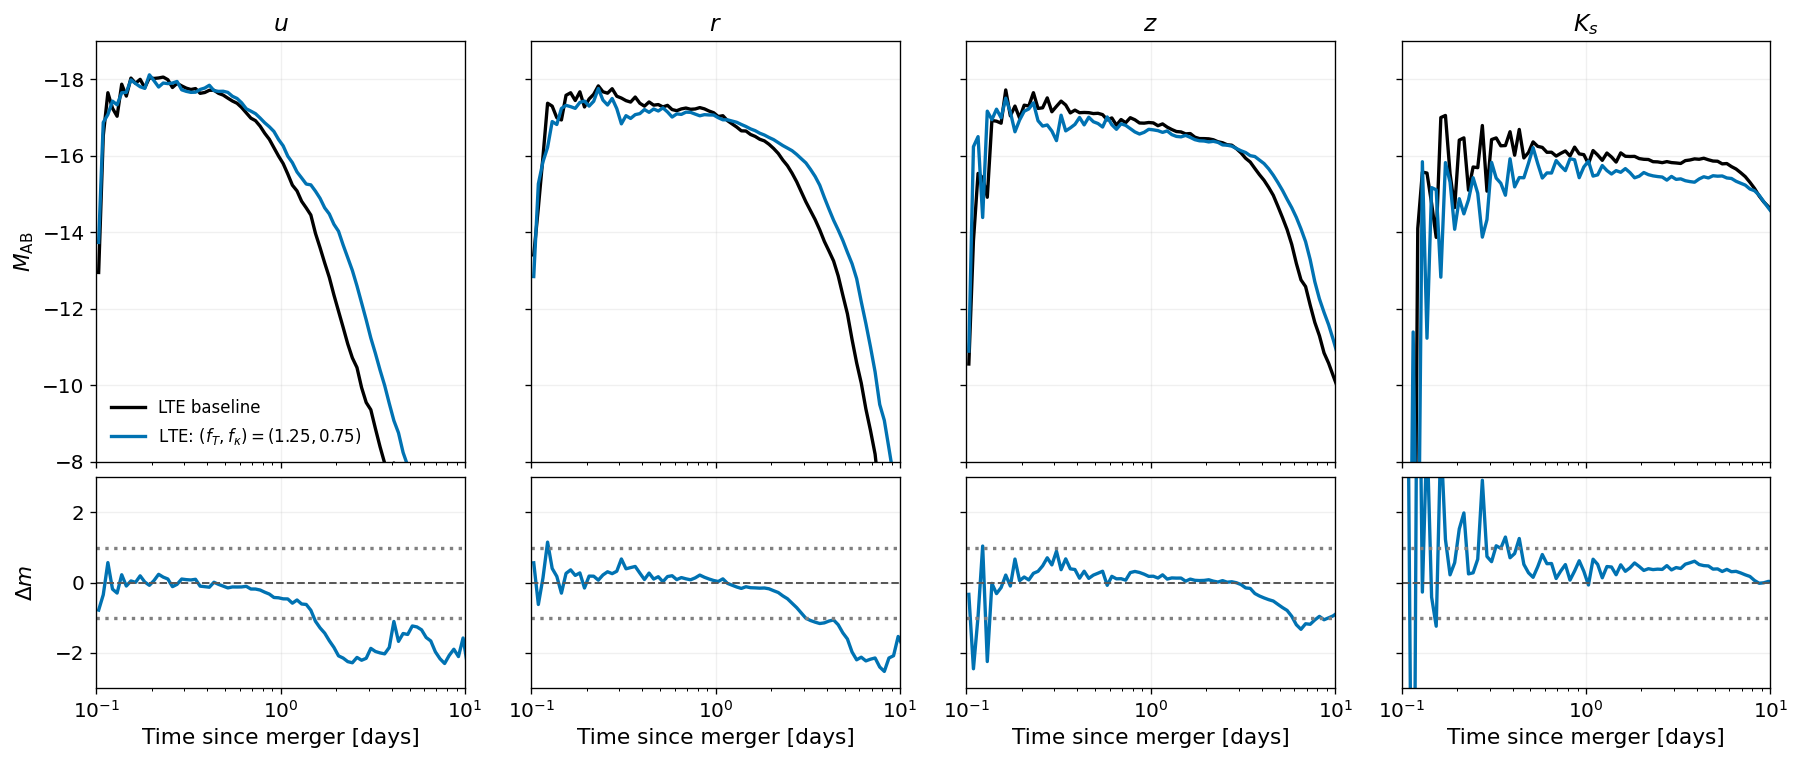

| Model | Filter | Peak time [d] | Peak magnitude | Shift from baseline |
|---|---:|---:|---:|---:|
| LTE baseline | $u$ | 0.231 | -18.056 | +0.000 |
| LTE baseline | $r$ | 0.231 | -17.826 | +0.000 |
| LTE baseline | $z$ | 0.163 | -17.719 | +0.000 |
| LTE baseline | $K_s$ | 0.173 | -17.052 | +0.000 |
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $u$ | 0.194 | -18.115 | -0.078 |
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $r$ | 0.231 | -17.756 | +0.070 |
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $z$ | 0.163 | -17.505 | +0.215 |
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $K_s$ | 0.517 | -16.211 | +0.150 |

| Model | Filter | max $|\Delta m|$ (0.2--10 d) | Time [d] |
|---|---:|---:|---:|
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $u$ | 2.308 | 7.750 |
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $r$ | 2.534 | 8.210 |
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $z$ | 1.333 | 6.520 |
| LTE: $(f_T,f_\kappa)=(1.25,0.75)$ | $K_s$ | 2.919 | 0.274 |

In [218]:
coupled_models = ["baseline", "LTE temp + opacity"]
plot_light_curve_comparison(
    coupled_models,
    "03_temperature_plus_opacity_tests",
)
peak_table(coupled_models)
maximum_difference_table(coupled_models)

### Reading the joint comparison

Increasing $T_{\rm gas}$ can change the ionization stages of the ejecta, while decreasing $\kappa_{\rm bb}$ generally facilitates photon escape. The two contributions can sum up or oppose one another in different bands and at different epochs.

# 3. Temperature, opacity, and high-temperature absorption together

The final two calculations combine the LTE-departure prescription,

$$
(f_T,f_\kappa)=(1.25,0.75),
$$

with either $k_{\rm abs}\times2$ or $k_{\rm abs}\times10$ above $2\times10^4$ K. These are the relevant end-to-end tests because both sources of uncertainty are allowed to affect the radiation field simultaneously.

/var/folders/mm/y34w0c493f155f_qjg5mprhw0000gp/T/ipykernel_10699/3999131828.py:29: RuntimeWarning: invalid value encountered in subtract
  ax_delta.plot(time_days[valid], (y - baseline)[valid],


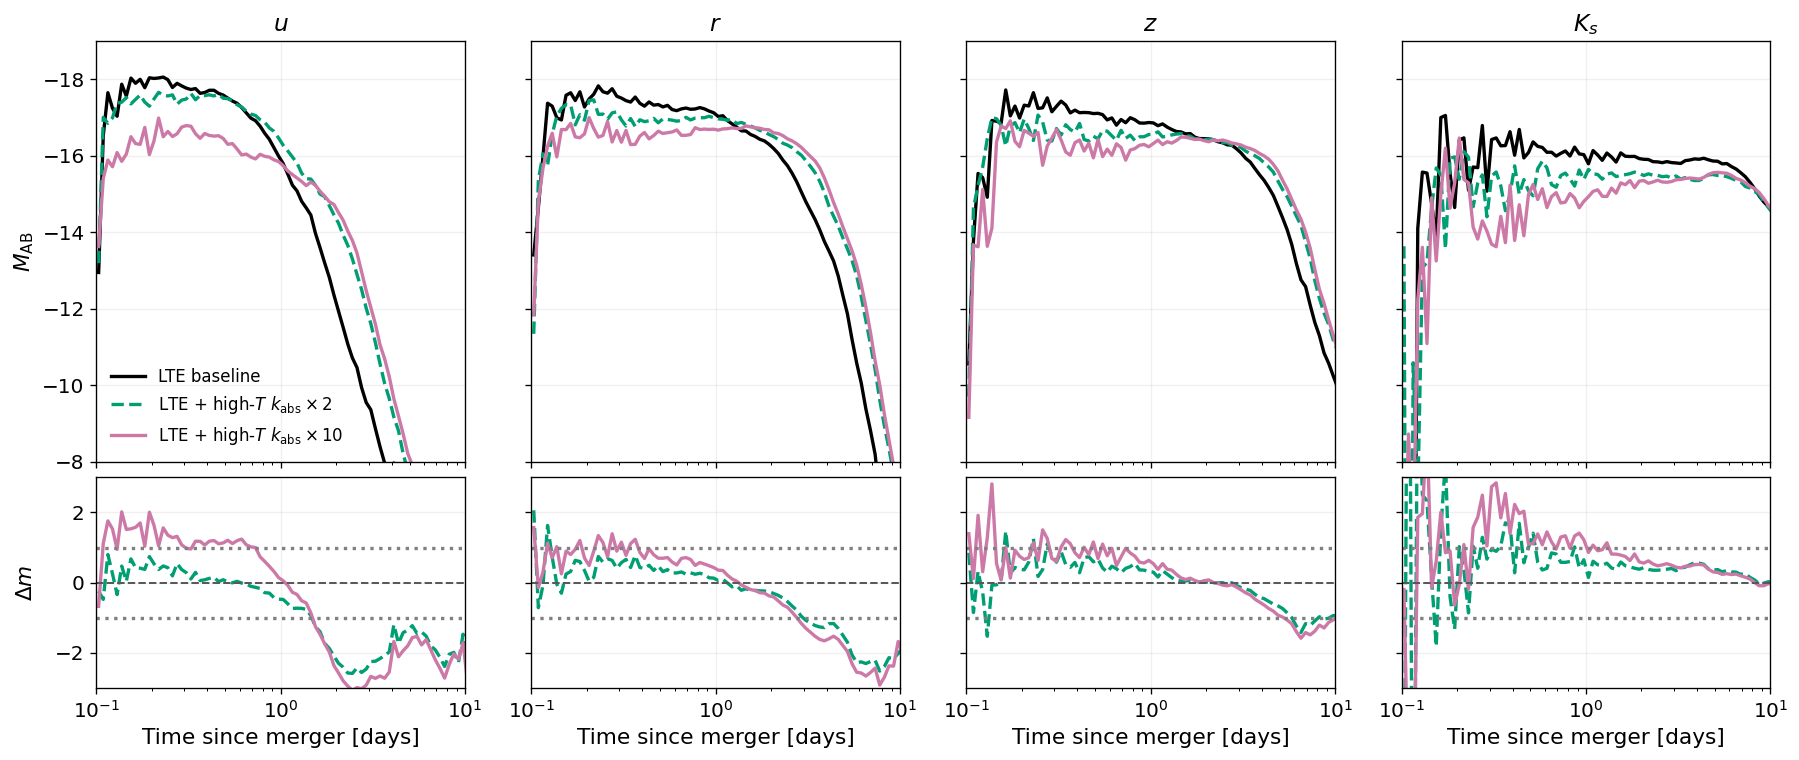

| Model | Filter | Peak time [d] | Peak magnitude | Shift from baseline |
|---|---:|---:|---:|---:|
| LTE baseline | $u$ | 0.231 | -18.056 | +0.000 |
| LTE baseline | $r$ | 0.231 | -17.826 | +0.000 |
| LTE baseline | $z$ | 0.163 | -17.719 | +0.000 |
| LTE baseline | $K_s$ | 0.173 | -17.052 | +0.000 |
| LTE + high-$T$ $k_{\rm abs}\times2$ | $u$ | 0.218 | -17.656 | +0.376 |
| LTE + high-$T$ $k_{\rm abs}\times2$ | $r$ | 0.218 | -17.460 | +0.146 |
| LTE + high-$T$ $k_{\rm abs}\times2$ | $z$ | 0.244 | -17.062 | +0.174 |
| LTE + high-$T$ $k_{\rm abs}\times2$ | $K_s$ | 0.218 | -16.106 | +0.360 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $u$ | 0.218 | -16.984 | +1.048 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $r$ | 0.206 | -16.996 | +0.487 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $z$ | 0.173 | -16.913 | +0.128 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $K_s$ | 0.206 | -16.463 | -0.055 |

| Model | Filter | max $|\Delta m|$ (0.2--10 d) | Time [d] |
|---|---:|---:|---:|
| LTE + high-$T$ $k_{\rm abs}\times2$ | $u$ | 2.591 | 2.448 |
| LTE + high-$T$ $k_{\rm abs}\times2$ | $r$ | 2.525 | 7.750 |
| LTE + high-$T$ $k_{\rm abs}\times2$ | $z$ | 1.422 | 6.520 |
| LTE + high-$T$ $k_{\rm abs}\times2$ | $K_s$ | 1.705 | 0.366 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $u$ | 3.072 | 2.448 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $r$ | 2.922 | 7.750 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $z$ | 1.587 | 6.520 |
| LTE + high-$T$ $k_{\rm abs}\times10$ | $K_s$ | 2.846 | 0.326 |

In [219]:
combined_models = ["baseline", "LTE_highT-kabs2", "LTE_highT-kabs10"]#, "LTE temp + opacity"
plot_light_curve_comparison(
    combined_models,
    "04_combined_LTE_and_high_temperature_tests",
)
peak_table(combined_models)
maximum_difference_table(combined_models)

### Reading the combined comparison

- Compare the LTE model with `highT kabs×2/×10` to isolate the additional high-temperature-absorption effect in the modified LTE calculation.
- Compare these shifts with the high-temperature-only section to see whether the response depends strongly on the LTE-departure prescription.

# Main messages

1. **High-temperature bound-bound opacity:** multiplying $k_{\rm abs}$ by factors of 2 and 10 above $2\times10^4$ K tests whether opacity missing from the available ionization stages could alter the early kilonova emission.
2. **Temperature sensitivity:** allowing $T_{\rm gas}$ to depart from $T_R$ produces the clearest individual LTE-related change because it also alters the ionization and opacity selected from the LTE tables.
3. **Bound--bound opacity sensitivity:** an additional density-dependent correction to $\kappa_{\rm bb}$ provides a simple bracket on population-related opacity errors.
4. **Net LTE-related effect:** the calculation combines the temperature and bound--bound-opacity changes.
5. **Both uncertainty sources:** the LTE + $highT-k_{\rm abs}\times2/\times10$ calculations show their joint effect rather than assuming that separate light-curve shifts can simply be added.
6. **Scope:** the calculations quantify sensitivity to plausible directions and amplitudes of missing physics for this ejecta model. They do not replace opacity calculations containing the missing ions or a rate-equation NLTE solution.

## Optional extensions

- Repeat the comparison for additional viewing angles instead of relying on observer index 10 (change VIEW_INDEX).
- Compare a more massive ejecta model at the same absolute epochs. Its higher density should delay activation of the density-based LTE-departure prescription, but at the same time it will lead to hotter ejecta potentially going above the 2e4 K temperature
- Extend the investigation to spectra and bolometric light curves